In [2]:
# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# LOAD DATA

df = pd.read_csv("advanced_metallurgy_dataset.csv")

In [4]:
# 2. DEFINE FEATURES (X) & TARGET (y)

X = df[[
    "C","Cr","Ni","Mn",
    "Austenite_Temp","Temper_Temp",
    "Holding_Time","Cooling_Rate",
    "Ferrite","Pearlite","Martensite",
    "Grain_Size"
]]

In [5]:
# Target (output)
y = df["Hardness"]

In [6]:
# 3. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (120, 12)
Testing size: (30, 12)


In [8]:
# 4. RANDOM FOREST (Bagging)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [9]:
# 5. GRADIENT BOOSTING (Boosting)

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [10]:
# 6. EVALUATION

print("\n--- Random Forest ---")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

print("\n--- Gradient Boosting ---")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("R2 Score:", r2_score(y_test, y_pred_gb))


--- Random Forest ---
MAE: 14.760666666666664
R2 Score: 0.9461556520282118

--- Gradient Boosting ---
MAE: 10.73711266877992
R2 Score: 0.9697528643853642


In [13]:
# OVERFITTING CHECK
print("Random Forest")
print("Train Score:", rf_model.score(X_train, y_train))
print("Test Score:", rf_model.score(X_test, y_test))

Random Forest
Train Score: 0.9929402662560766
Test Score: 0.9461556520282118


In [14]:
#OVERFITTING CHECK
print("Gradient Boosting")
print("Train Score:", gb_model.score(X_train, y_train))
print("Test Score:", gb_model.score(X_test, y_test))

Gradient Boosting
Train Score: 0.9998050467882276
Test Score: 0.9697528643853642


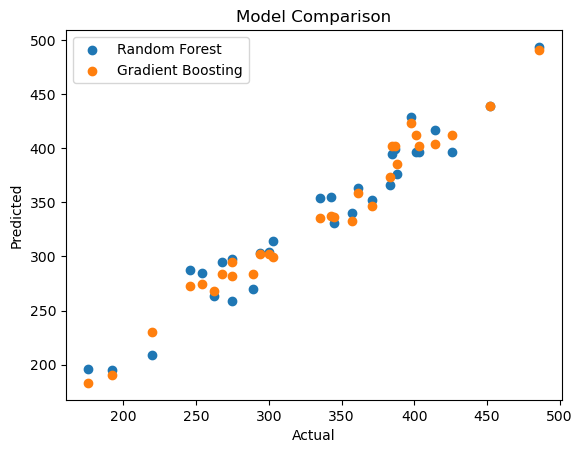

In [21]:
# VISUALIZATION

plt.figure()
plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_gb, label="Gradient Boosting")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Model Comparison")
plt.show()

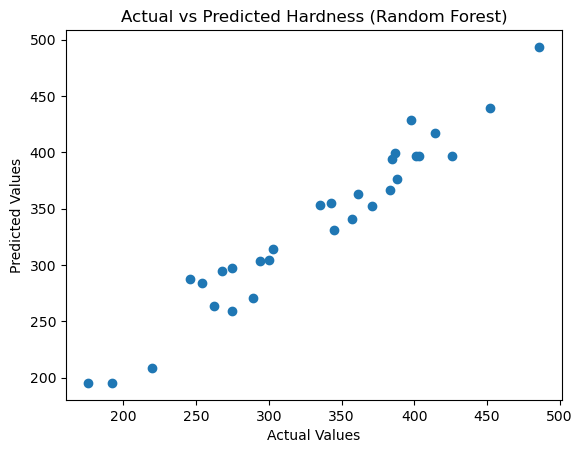

In [28]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Hardness (Random Forest)")
plt.show()

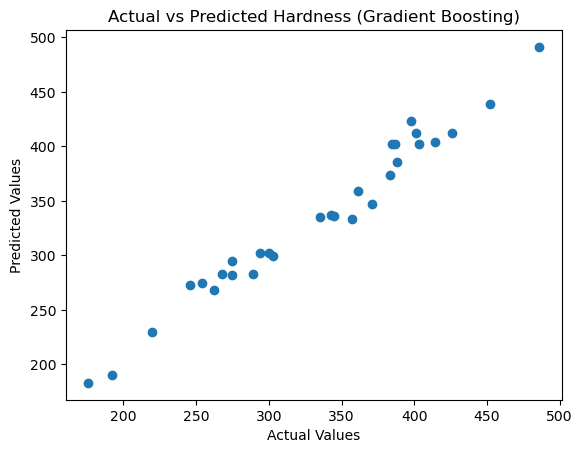

In [29]:
plt.figure()
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Hardness (Gradient Boosting)")
plt.show()

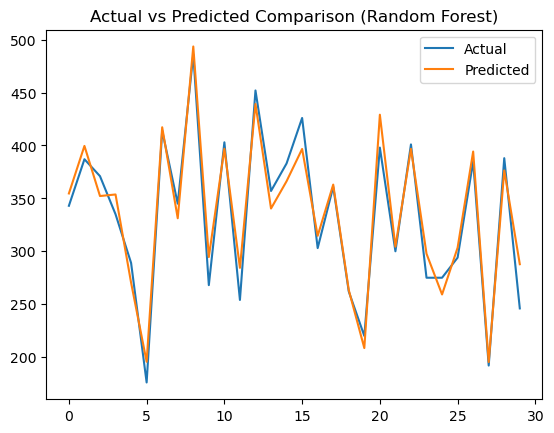

In [30]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Comparison (Random Forest)")
plt.show()

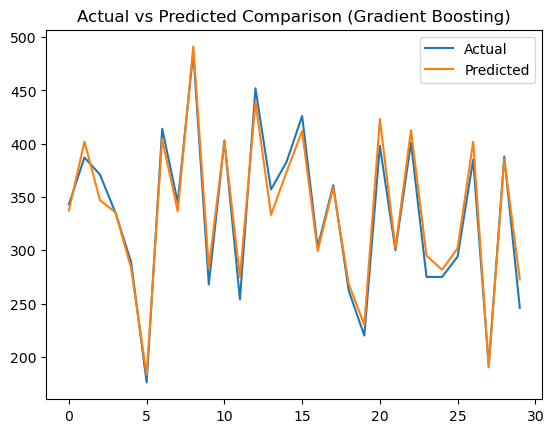

In [31]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gb, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Comparison (Gradient Boosting)")
plt.show()